# Phase 4: Modelling

**CRISP-DM Phase Description:**  
In this phase, various modelling techniques are selected and applied, and their parameters are calibrated to optimal values. Typically, there are several techniques for the same data mining problem type, and some techniques have specific requirements on the form of the data. This may require stepping back to the Data Preparation phase.

---

In [1]:
# Standard library imports for this phase
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score,silhouette_score
)

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
# Load the prepared dataset
DATA_PATH = "../data/processed/uber_prepared_data.csv"

df_final = pd.read_csv(DATA_PATH)

print(f"Loaded prepared dataset: {df_final.shape[0]} rows x {df_final.shape[1]} columns")
df_final.head()

Loaded prepared dataset: 555752 rows x 8 columns


,datetime,latitude,longitude,hour,day,weekday,month,time_period
0,2014-04-01 00:11:00,0.858177,0.467912,-2.464574,1,-1.025062,4,Night
1,2014-04-01 00:17:00,-0.379095,-1.204160,-2.464574,1,-1.025062,4,Night
2,2014-04-01 00:21:00,-0.235770,-0.212680,-2.464574,1,-1.025062,4,Night
3,2014-04-01 00:28:00,0.559828,-0.008923,-2.464574,1,-1.025062,4,Night
4,2014-04-01 00:33:00,0.577378,0.104509,-2.464574,1,-1.025062,4,Night


---
### Task 1: Select Modelling Techniques

Determine which algorithms are appropriate for your data mining problem type. Consider:

- **Problem Type:** Classification, regression, clustering, anomaly detection, etc.
- **Algorithm Candidates:** List several algorithms suitable for your problem (e.g., Logistic Regression, Random Forest, SVM, k-NN, XGBoost, Neural Networks).
- **Assumptions:** Document each technique's assumptions and whether your data satisfies them (e.g., linearity, normality, independence).
- **Justification:** Explain why each technique was selected as a candidate.

**Instructions:** Document your selected modelling techniques and the rationale for each choice.

In [3]:
# TODO: Select and document your modelling techniques here.

modelling_techniques = {
    "problem_type": "Clustering (Unsupervised Learning)",
    "target_variable": None,
    "candidate_models": [
        {
            "name": "K-Means Clustering",
            "library": "sklearn.cluster.KMeans",
            "justification": "Efficient and widely used clustering algorithm suitable for identifying high-demand geographic zones based on spatial and temporal features.",
            "assumptions": "Assumes clusters are spherical and similar in size. Works well with scaled numerical data, which is satisfied in this dataset."
        },
        {
            "name": "DBSCAN",
            "library": "sklearn.cluster.DBSCAN",
            "justification": "Density-based clustering method that can identify arbitrarily shaped clusters and detect noise (outliers), useful for real-world spatial data like ride pickups.",
            "assumptions": "Assumes clusters are dense regions separated by low-density areas. Sensitive to parameter selection (eps, min_samples), but suitable for geographic data."
        },
        {
            "name": "Hierarchical Clustering",
            "library": "sklearn.cluster.AgglomerativeClustering",
            "justification": "Provides a hierarchical structure of clusters and does not require specifying the number of clusters in advance, useful for exploratory analysis.",
            "assumptions": "Assumes a meaningful distance metric exists between points. Computationally expensive for large datasets, so may require sampling."
        }
    ]
}
# Display the selected techniques
print(f"Problem Type: {modelling_techniques['problem_type']}")
print(f"Target Variable: {modelling_techniques['target_variable']}")
print(f"\nCandidate Models:")
for i, model in enumerate(modelling_techniques['candidate_models'], 1):
    print(f"  {i}. {model['name']} — {model['justification']}")

Problem Type: Clustering (Unsupervised Learning)
Target Variable: None

Candidate Models:
  1. K-Means Clustering — Efficient and widely used clustering algorithm suitable for identifying high-demand geographic zones based on spatial and temporal features.
  2. DBSCAN — Density-based clustering method that can identify arbitrarily shaped clusters and detect noise (outliers), useful for real-world spatial data like ride pickups.
  3. Hierarchical Clustering — Provides a hierarchical structure of clusters and does not require specifying the number of clusters in advance, useful for exploratory analysis.


In [4]:
# Import the specific model classes you plan to use
# Example imports (uncomment and modify as needed):

# Clustering

# Clustering models are used because the dataset has no labeled target variable.
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Evaluation metric for clustering performance
# Measures how well-separated and compact the clusters are
from sklearn.metrics import silhouette_score

---
### Task 2: Generate Test Design

Before building the model, you must design the test strategy to ensure results are valid and generalisable. Key decisions include:

- **Train/Test Split:** What percentage of data is used for training vs. testing? A common split is 70/30 or 80/20.
- **Validation Strategy:** Will you use a hold-out validation set, k-fold cross-validation, or stratified sampling?
- **Reproducibility:** Set a random seed to ensure results are reproducible.
- **Stratification:** For classification tasks with imbalanced classes, use stratified splitting to maintain class proportions.

**Instructions:** Split your data into training and test sets. Document and justify your test design choices.

In [5]:
# TODO: Define test design (Clustering - no train/test split needed)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


df_sample = df_final.sample(n=50000, random_state=42)

print(f"Full dataset size   : {df_final.shape[0]}")
print(f"Sampled dataset size: {df_sample.shape[0]}")
print(f"Random seed used    : {RANDOM_SEED}")

Full dataset size   : 555752
Sampled dataset size: 50000
Random seed used    : 42


In [11]:
# Document and justify test design (Clustering)

test_design = {
    "split_ratio": "N/A (No train-test split used)",
    "validation_strategy": "Sampling + internal validation (Silhouette Score)",
    "stratified": False,
    "random_seed": RANDOM_SEED,
    "justification": (
        "Since this is an unsupervised clustering problem, there are no labeled target variables "
        "to enable train-test splitting or stratified sampling. Instead, a random seed is used to ensure reproducibility, "
        "and a sampled subset of the data is used for computational efficiency. Model validation is performed using "
        "internal metrics such as the Silhouette Score rather than traditional train-test evaluation."
    )
}


In [7]:
rows = []
for key, value in test_design.items():
    if isinstance(value, list):
        content = "\n".join(f"• {item}" for item in value)
    elif isinstance(value, dict):
        content = "\n".join(
            f"• {k.replace('_', ' ').title()}: {', '.join(v) if isinstance(v, list) else v}"
            for k, v in value.items()
        )
    else:
        content = value
    rows.append({
        "Section": key.replace("_", " ").title(),
        "Details": content
    })
df_test_design = pd.DataFrame(rows)
df_test_design.style.set_properties(**{
    'text-align': 'left',
    'white-space': 'pre-wrap',
    'vertical-align': 'top',
    'padding': '10px 16px'
}).hide(axis='index')

Section,Details
Split Ratio,N/A (No train-test split used)
Validation Strategy,Sampling + internal validation (Silhouette Score)
Stratified,False
Random Seed,42
Justification,"Since this is an unsupervised clustering problem, there are no labeled target variables to enable train-test splitting or stratified sampling. Instead, a random seed is used to ensure reproducibility, and a sampled subset of the data is used for computational efficiency. Model validation is performed using internal metrics such as the Silhouette Score rather than traditional train-test evaluation."


---
### Task 3: Build Model

Run the selected modelling techniques on the prepared training dataset. This involves:

- **Training:** Fit each candidate model on the training data.
- **Hyperparameter Tuning:** Optimise model parameters using techniques such as Grid Search or Random Search with cross-validation.
- **Multiple Iterations:** It is common to build multiple models and iterate on parameters before settling on the best performers.

**Instructions:** Train your candidate models and, where appropriate, perform hyperparameter tuning.

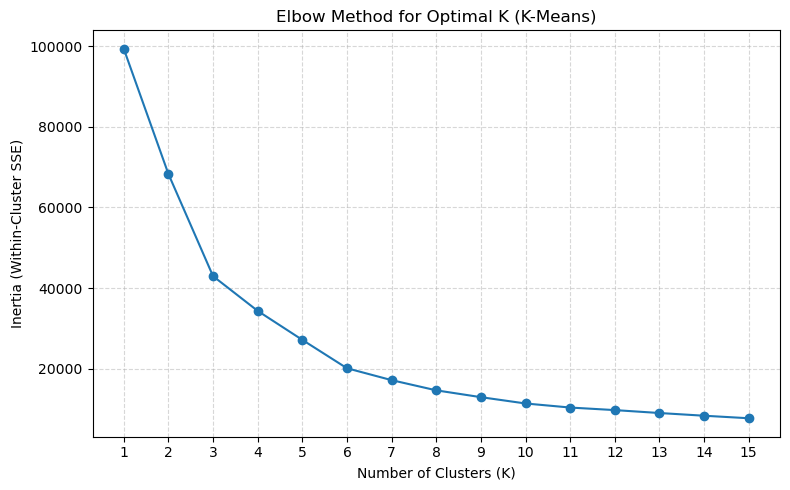

In [10]:
# Elbow method for K-Means to determine optimal K
K = range(1, 16)  
features = df_sample[['latitude', 'longitude']]
inertia = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker='o')
plt.title("Elbow Method for Optimal K (K-Means)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Within-Cluster SSE)")
plt.xticks(K)  # makes K values clearer
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [14]:
# TODO: Build and train your models.
# Store trained models in a dictionary for easy comparison.
trained_models = {}

# Use dataset sample 
data = df_sample.copy()

# Select only numerical features for clustering
features = data[['latitude', 'longitude']]


# ---Model 1: K-Means---
kmeans = KMeans(n_clusters=5, random_state=RANDOM_SEED)
kmeans.fit(features)

trained_models['K-Means'] = kmeans



# ---Model 2: DBSCAN---
dbscan = DBSCAN(eps=0.01, min_samples=10)
dbscan.fit(features)

trained_models['DBSCAN'] = dbscan



# ---Model 3: Agglomerative Clustering---
agg = AgglomerativeClustering(n_clusters=5)
agg.fit(features)

trained_models['Agglomerative Clustering'] = agg


print(f"Successfully trained {len(trained_models)} clustering models.")

Successfully trained 3 clustering models.


---
### Task 4: Assess Model

Interpret and compare the results of your trained models. Assessment should consider:

- **Performance Metrics:** Evaluate each model using the success metrics defined in Phase 1 (e.g., accuracy, F1-score, RMSE, AUC-ROC).
- **Cross-Validation:** Use cross-validation scores to understand variance and reliability.
- **Comparison Table:** Create a summary table ranking all models side by side.
- **Confusion Matrix / Error Analysis:** Visualise where the model succeeds and fails.
- **Model Selection:** Select the best-performing model based on the combined assessment.

**Instructions:** Evaluate all trained models, compare them, and select the best one.

In [ ]:
#Evaluate and compare all trained models.
results = []

features = df_sample[['latitude', 'longitude']].values  

for name, model in trained_models.items():

    labels = model.labels_

    # Ensure same length safety
    if len(labels) != len(features):
        print(f"Skipping {name} due to mismatch: {len(labels)} vs {len(features)}")
        continue

    # If DBSCAN or noise exists
    unique_labels = set(labels)

    if len(unique_labels) > 1:
        score = silhouette_score(features, labels)
    else:
        score = -1  # invalid clustering

    results.append({
        "Model": name,
        "Silhouette Score": score,
        "Clusters Found": len(unique_labels) - (1 if -1 in unique_labels else 0)
    })

results_df = pd.DataFrame(results).set_index("Model")

print("=== CLUSTER MODEL COMPARISON ===")
print(results_df.sort_values("Silhouette Score", ascending=False))

=== CLUSTER MODEL COMPARISON ===
                          Silhouette Score  Clusters Found
Model                                                     
Agglomerative Clustering          0.446907               5
K-Means                           0.371788               5
DBSCAN                           -0.365686             476



=== Best Model: Agglomerative Clustering ===


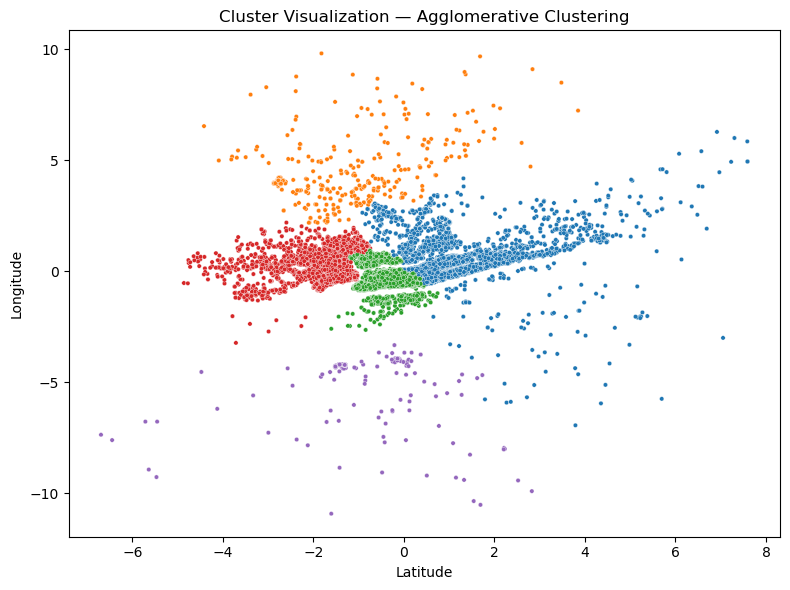

In [16]:
# Choose best model based on silhouette score
best_model_name = results_df['Silhouette Score'].idxmax()
best_model = trained_models[best_model_name]

features = df_sample[['latitude', 'longitude']]
# Get cluster labels
if hasattr(best_model, "labels_"):
    labels = best_model.labels_
else:
    labels = best_model.predict(features)

print(f"\n=== Best Model: {best_model_name} ===")

# Visualise clusters
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=features['latitude'],
    y=features['longitude'],
    hue=labels,
    palette='tab10',
    s=10,
    legend=False
)

plt.title(f"Cluster Visualization — {best_model_name}")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.tight_layout()
plt.show()

In [12]:
# K-Means cluster centers
kmeans = trained_models['K-Means']

labels_kmeans = kmeans.labels_
centers = kmeans.cluster_centers_

plt.figure(figsize=(8,6))

# Data points
plt.scatter(
    features['latitude'],
    features['longitude'],
    c=labels_kmeans,
    cmap='tab10',
    s=10,
    alpha=0.6
)

# Cluster centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    c='red',
    s=200,
    marker='X',
    label='Cluster Centers'
)

plt.title("K-Means Clusters with Centroids (NYC Hotspots)")
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'trained_models' is not defined

In [ ]:
#Visualize DBSCAN clusters separately to show noise points   
labels_dbscan = trained_models['DBSCAN'].labels_

plt.figure(figsize=(8,6))
plt.scatter(
    features['latitude'],
    features['longitude'],
    c=labels_dbscan,
    cmap='tab10',
    s=10
)

plt.title('DBSCAN Clustering')
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation for the selected best model

features = df_sample[['latitude', 'longitude']].values

scores = []

# Repeat clustering multiple times with different samples
for i in range(5):
    sample = df_sample.sample(frac=0.8, random_state=i)
    X = sample[['latitude', 'longitude']].values

    model = KMeans(n_clusters=5, random_state=i, n_init=10)
    labels = model.fit_predict(X)

    score = silhouette_score(X, labels)
    scores.append(score)

print("=== CLUSTER STABILITY TEST ===")
print(f"Silhouette Scores: {np.round(scores, 4)}")
print(f"Mean Score: {np.mean(scores):.4f}")
print(f"Std Dev:   {np.std(scores):.4f}")
results_df.to_csv("../data/processed/model_results.csv")